In [ ]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np
import matplotlib.pyplot as plt


# Stadardised Formation Cycling Bham group
exp = pybamm.Experiment( [("Charge at C/20 until 4.2 V",
                           "Hold at 4.2 V for 1 hours", 
                           "Hold at 4.2 V until 2.5 mA", 
                           "Discharge at C/20 until 2.5 V",
                           "Charge at C/20 until 3.8 V",
                           "Hold at 3.8 V for 1 hours"
                           )])

# no_cycles = 1
# exp = pybamm.Experiment(
#     [("Charge at C/20 until 4.2 V",
#       "Rest for 5 hours",
#       "Discharge at C/20 until 2.5 V",
#       "Rest for 5 hours",
#       )]* no_cycles )

param=pybamm.ParameterValues("Chen2020")
param['Initial inner SEI thickness [m]']=1e-13
param['Initial outer SEI thickness [m]']=1e-13


In [ ]:

models = [pybamm.lithium_ion.DFN(),
          pybamm.lithium_ion.SPMe(),
          pybamm.lithium_ion.SPM(),
          pybamm.lithium_ion.SPM({"particle": "uniform profile"})]
models_names = ["DFN", "SPMe", "SPM", "RM"]

pybamm.settings.max_y_value = 1000000000
solver = pybamm.CasadiSolver(mode="safe")

sims = [pybamm.Simulation(model, parameter_values=param,
                          experiment=exp, solver=solver) for model in models]
sols = [sim.solve(initial_soc=0) for sim in sims]

In [ ]:
# models[0].variable_names()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import scienceplots
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)
colors = [cmap(i) for i in range(4)]  # 4 colours
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
linestyles = ["-", "--", "-.", ":"]

# First subplot
for index in range(0, 4):
    time = sols[index]["Time [h]"].entries
    voltage = sols[index]["Terminal voltage [V]"].entries
    axs[0].plot(time, voltage, label=models_names[index],
                color=colors[index], linewidth=2)
axs[0].legend(fontsize=12)
axs[0].set_xlabel("Time [h]", fontsize=12)
axs[0].set_ylabel("Voltage [V]", fontsize=12)
axs[0].tick_params(axis='both', which='major', labelsize=12)
# Replace x and y with the coordinates where you want to place the text
axs[0].text(50, 4.0, '(a)', fontsize=14)


# Second subplot
t_max = max(sol["Time [s]"].entries[-1] for sol in sols)
t = np.linspace(0, t_max, 1000000)
for index in range(1, 4):
    voltage = sols[0]["Terminal voltage [V]"](
        t) - sols[index]["Terminal voltage [V]"](t)
    axs[1].plot(t/3600, voltage, label=models_names[0] +
                " -- " + models_names[index],  color=colors[index], linewidth=2)
axs[1].legend(fontsize=14)
axs[1].set_xlabel("Time [h]", fontsize=12)
axs[1].tick_params(axis='both', which='major', labelsize=12)
axs[1].text(50, 0.15, '(b)', fontsize=14)

# axs[1].set_ylabel("Voltage [V]")

# Save the figure as a high-quality PDF
# plt.tight_layout()
# plt.savefig("figure.pdf", format='pdf', dpi=300)

Numerical Results

In this section, we calculate the current density due to SEI for all models with the following parameters:

In [1]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np

# Stadardised Formation Cycling Bham group
no_cycles = 2
exp = pybamm.Experiment( [("Charge at C/20 until 4.2 V",
                           "Hold at 4.2 V for 1 hours", 
                           "Hold at 4.2 V until 2.5 mA", 
                           "Discharge at C/20 until 2.5 V",
                           "Charge at C/20 until 3.8 V",
                           "Hold at 3.8 V for 1 hours"
                           )]* no_cycles)

# no_cycles = 2
# exp = pybamm.Experiment(
#     [("Charge at C/20 until 4.2 V",
#       "Rest for 5 hours",
#       "Discharge at C/20 until 2.5 V",
#       "Rest for 5 hours",
#       )]* no_cycles )
# The SEI layer considered as one layer here, 
# so in all equations if there were Outer_or inner they have been removed

k_sei =[1.0e-12, 1.0e-18, 1.0e-19]
params = []
for i in range(0, len(k_sei)):
  param=pybamm.ParameterValues("Chen2020")
  param['Initial inner SEI thickness [m]']=5e-13
  param['Initial outer SEI thickness [m]']=5e-13
  param['SEI kinetic rate constant [m.s-1]'] =k_sei[i]
  param['Outer SEI solvent diffusivity [m2.s-1]' ]=2.5e-22
  param['Bulk solvent concentration [mol.m-3]']= 4541.0
  # param['Inner SEI open-circuit potential [V]']=0.4
  # param['Outer SEI open-circuit potential [V]']=0.4
  param['SEI open-circuit potential [V]'] = 0.8
  param['Inner SEI electron conductivity [S.m-1]']=8.5e-14
  param['SEI lithium ion conductivity [S.m-1]']=1e-8
  param['Inner SEI lithium interstitial diffusivity [m2.s-1]']=1e-15
  param['Lithium interstitial reference concentration [mol.m-3]']=1000
  # This has been used fro Kolzenberg model 
  param['SEI reaction exchange current density [A.m-2]'] = 7.04e-5
  params.append(param)

# param=pybamm.ParameterValues("Chen2020")
# param['Initial inner SEI thickness [m]']=5e-18
# param['Initial outer SEI thickness [m]']=5e-18
# param['SEI kinetic rate constant [m.s-1]'] =1.0e-19
# param['Outer SEI solvent diffusivity [m2.s-1]' ]=2.5e-22
# param['Bulk solvent concentration [mol.m-3]']= 4541.0
# # param['Inner SEI open-circuit potential [V]']=0.4
# # param['Outer SEI open-circuit potential [V]']=0.4
# param['SEI open-circuit potential [V]'] = 0.8
# param['Inner SEI electron conductivity [S.m-1]']=8.5e-14
# param['SEI lithium ion conductivity [S.m-1]']=1e-8
# param['Inner SEI lithium interstitial diffusivity [m2.s-1]']=1e-15
# param['Lithium interstitial reference concentration [mol.m-3]']=1000
# # This has been used fro Kolzenberg model 
# param['SEI reaction exchange current density [A.m-2]'] = 7.04e-5
# params.append(param)
  
  
  
# param=pybamm.ParameterValues("Chen2020")
# param['Initial inner SEI thickness [m]']=5e-18
# param['Initial outer SEI thickness [m]']=5e-18
# param['SEI kinetic rate constant [m.s-1]'] =8.0e-18
# param['Outer SEI solvent diffusivity [m2.s-1]' ]=2.5e-22
# param['Bulk solvent concentration [mol.m-3]']= 4541.0
# # param['Inner SEI open-circuit potential [V]']=0.4
# # param['Outer SEI open-circuit potential [V]']=0.4
# param['SEI open-circuit potential [V]'] = 0.8
# param['Inner SEI electron conductivity [S.m-1]']=8.5e-14
# param['SEI lithium ion conductivity [S.m-1]']=1e-8
# param['Inner SEI lithium interstitial diffusivity [m2.s-1]']=1e-15
# param['Lithium interstitial reference concentration [mol.m-3]']=1000
# # This has been used fro Kolzenberg model 
# param['SEI reaction exchange current density [A.m-2]'] = 7.04e-5
# params.append(param)


/home/kawamanmi/Projects/PyBaMM


In [2]:
sei_options = ["ec reaction limited", "reaction limited",
               "solvent-diffusion limited", "interstitial-diffusion limited", "electron-migration limited", "Kolzenberg2020"]
sei_options = ['reaction limited',
               'solvent-diffusion limited', 'ec reaction limited']
sei_options = ['ec reaction limited',
               'ec reaction limited', 'ec reaction limited',
               ]
models = [pybamm.lithium_ion.SPM({"particle": "uniform profile",
                                  "SEI": sei_option}) for sei_option in sei_options]


pybamm.settings.max_y_value = 1000000000
solver = pybamm.CasadiSolver(mode="safe")

sims = [pybamm.Simulation(model, parameter_values=params[index],
                          experiment=exp, solver=solver) for index, model in enumerate(models)]
sols = [sim.solve(initial_soc=0) for sim in sims]

In [3]:
# import matplotlib.pyplot as plt
# import scienceplots
# import matplotlib.cm as cm
# import matplotlib.ticker as ticker


# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# plt.style.use('science')  # Use the 'science' style
# cmap = cm.get_cmap('tab10')  # Colour map (there are many others)

# plt.rcParams["font.family"] = "DejaVu Sans"

# linestyles = ["-", "--", "-.", ":", "-"]

# fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# label_models = [
#     'Diffusion mode $\kappa_\mathrm{SEI, 0}=10^{-12}$',  'Mixed mode  $\kappa_\mathrm{SEI, 0}=10^{-18}$', 'Reaction mode $\kappa_\mathrm{SEI, 0}=10^{-19}$']

# # First plot
# for index, sol in enumerate(sols):
#     axs[0].plot(sol['Time [h]'].entries,
#                 sol['X-averaged negative total SEI thickness [m]'].entries*1e9, label=label_models[index], linestyle=linestyles[index], linewidth=2)

# axs[0].legend(fontsize=14)
# axs[0].set_xlabel("Time [h]", fontsize=14)
# axs[0].set_ylabel("SEI thickness [nm]", fontsize=14)
# axs[0].tick_params(axis='both', which='major', labelsize=14)

# # Second plot
# for index, sol in enumerate(sols):
#     discharge_capacity = (
#         (5 - sol['Discharge capacity [A.h]'].entries)/5-1)*100
#     sei_current_density = np.abs(
#         sol['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries)
#     current = sol['Current [A]'].entries

#     mask = current < 0

#     axs[1].plot(discharge_capacity[mask],
#                 sei_current_density[mask], label=label_models[index], linestyle=linestyles[index], linewidth=2)

# axs[1].legend(fontsize=14)
# axs[1].set_xlabel("Discharge capacity [%]", fontsize=14)
# axs[1].set_ylabel("SEI interfacial current density [A.m-2]", fontsize=14)
# axs[1].tick_params(axis='both', which='major', labelsize=14)

# # plt.tight_layout()
# # plt.savefig("figure.pdf", format='pdf', dpi=300)
# plt.show()

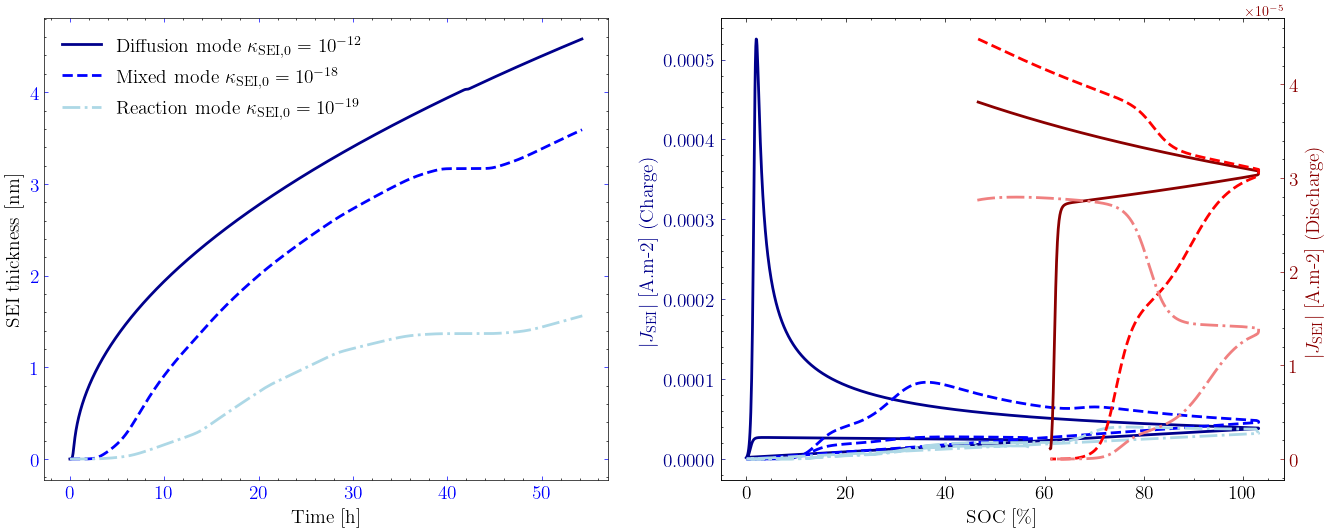

In [4]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm
import matplotlib.ticker as ticker
plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)

# plt.rcParams["font.family"] = "DejaVu Sans"

linestyles = ["-", "--", "-.", ":", "-"]

fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

label_models = [
    'Diffusion mode $\kappa_\mathrm{SEI, 0}=10^{-12}$',  'Mixed mode  $\kappa_\mathrm{SEI, 0}=10^{-18}$', 'Reaction mode $\kappa_\mathrm{SEI, 0}=10^{-19}$']
colors = ['darkblue', 'blue', 'lightblue']
# First plot
for index, sol in enumerate(sols):
    axs[0].plot(sol.cycles[0]['Time [h]'].entries,
                sol.cycles[0]['X-averaged negative total SEI thickness [m]'].entries*1e9,
                label=label_models[index], linestyle=linestyles[index], linewidth=2, color=colors[index])

axs[0].legend(fontsize=14)
axs[0].set_xlabel("Time [h]", fontsize=14)
axs[0].set_ylabel("SEI thickness [nm]", fontsize=14)
axs[0].tick_params(axis='both', which='major', labelsize=14, colors='blue')

# Second plot
for index, sol in enumerate(sols):
    discharge_capacity = (
        (5 - sol.cycles[0]['Discharge capacity [A.h]'].entries)/5-1)*100
    sei_current_density = np.abs(
        sol.cycles[0]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries)
    current = sol.cycles[0]['Current [A]'].entries

    mask = current < 0

    axs[1].plot(discharge_capacity[mask],
                sei_current_density[mask], label=label_models[index],
                linestyle=linestyles[index], linewidth=2, color=colors[index])
# axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
# axs[1].set_ylabel('× 10^(-5)')
# formatter = ticker.FormatStrFormatter('%.1e')
# axs[1].yaxis.set_major_formatter(formatter)
# ylim = axs[1].get_ylim()
# order_of_magnitude = int(np.log10(ylim[1]))
# axs[1].set_ylim(0, 1 * 10**(order_of_magnitude - int(order_of_magnitude)))
# axs[1].text(0.02, 0.98, f'× 10$^{{{order_of_magnitude}}}$',
#             transform=axs[1].transAxes, fontsize=12, verticalalignment='top')

# Add legend


ax2 = axs[1].twinx()  # create a second y-axis that shares the same x-axis
colors = ['darkred', 'red', 'lightcoral']
for index, sol in enumerate(sols):
    discharge_capacity = (
        (5 - sol.cycles[0]['Discharge capacity [A.h]'].entries)/5-1)*100
    discharge_capacity = discharge_capacity[::-1]
    sei_current_density = np.abs(
        sol.cycles[0]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries)

    current = sol.cycles[0]['Current [A]'].entries

    mask = current > 0

    ax2.plot(discharge_capacity[mask],
             sei_current_density[mask], label=label_models[index],
             linestyle=linestyles[index], linewidth=2, color=colors[index])

# axs[1].legend(fontsize=14)
axs[1].set_xlabel("SOC [\%]", fontsize=14)
axs[1].set_ylabel(
    "$|J_\mathrm{SEI}|$ [A.m-2] (Charge)", fontsize=14, color='darkblue')
ax2.set_ylabel(
    "$|J_\mathrm{SEI}| $ [A.m-2] (Discharge)", fontsize=14, color='darkred')
axs[1].tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='y', which='major', labelsize=14, colors='darkred')
axs[1].tick_params(axis='y', which='major', labelsize=14, colors='darkblue')


# plt.tight_layout()
# plt.savefig("figure.pdf", format='pdf', dpi=300)
plt.show()

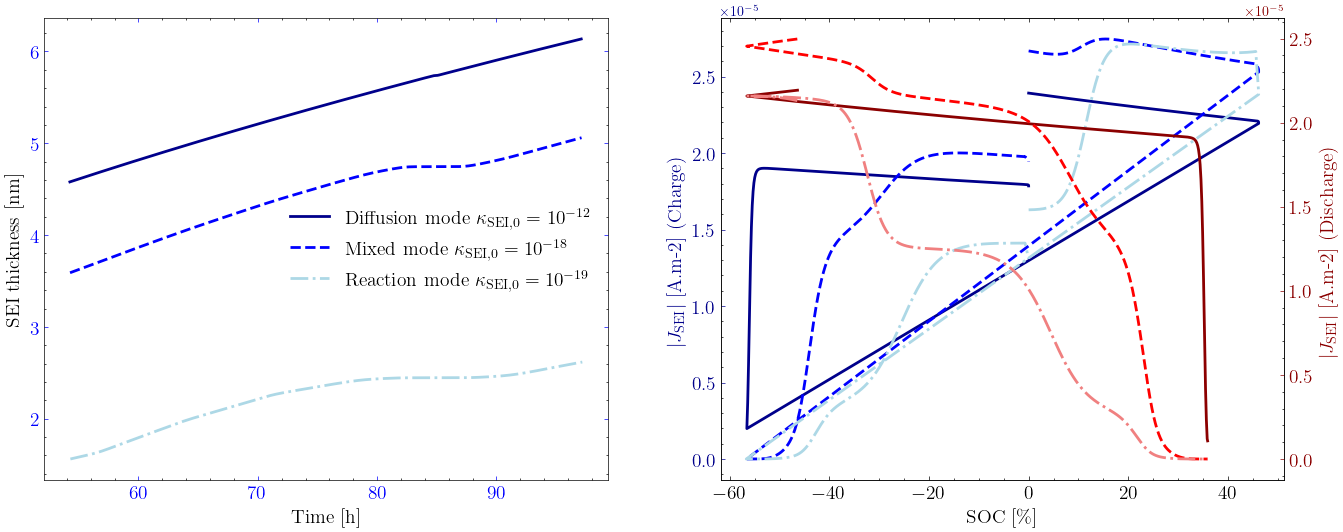

In [5]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm
import matplotlib.ticker as ticker
plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)

# plt.rcParams["font.family"] = "DejaVu Sans"

linestyles = ["-", "--", "-.", ":", "-"]

fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

label_models = [
    'Diffusion mode $\kappa_\mathrm{SEI, 0}=10^{-12}$',  'Mixed mode  $\kappa_\mathrm{SEI, 0}=10^{-18}$', 'Reaction mode $\kappa_\mathrm{SEI, 0}=10^{-19}$']
colors = ['darkblue', 'blue', 'lightblue']
# First plot
for index, sol in enumerate(sols):
    axs[0].plot(sol.cycles[1]['Time [h]'].entries,
                sol.cycles[1]['X-averaged negative total SEI thickness [m]'].entries*1e9,
                label=label_models[index], linestyle=linestyles[index], linewidth=2, color=colors[index])

axs[0].legend(fontsize=14)
axs[0].set_xlabel("Time [h]", fontsize=14)
axs[0].set_ylabel("SEI thickness [nm]", fontsize=14)
axs[0].tick_params(axis='both', which='major', labelsize=14, colors='blue')

# Second plot
for index, sol in enumerate(sols):
    discharge_capacity = (
        (5 - sol.cycles[1]['Discharge capacity [A.h]'].entries)/5-1)*100
    sei_current_density = np.abs(
        sol.cycles[1]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries)
    current = sol.cycles[1]['Current [A]'].entries

    mask = current < 0

    axs[1].plot(discharge_capacity[mask],
                sei_current_density[mask], label=label_models[index],
                linestyle=linestyles[index], linewidth=2, color=colors[index])
# axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
# axs[1].set_ylabel('× 10^(-5)')
# formatter = ticker.FormatStrFormatter('%.1e')
# axs[1].yaxis.set_major_formatter(formatter)
# ylim = axs[1].get_ylim()
# order_of_magnitude = int(np.log10(ylim[1]))
# axs[1].set_ylim(0, 1 * 10**(order_of_magnitude - int(order_of_magnitude)))
# axs[1].text(0.02, 0.98, f'× 10$^{{{order_of_magnitude}}}$',
#             transform=axs[1].transAxes, fontsize=12, verticalalignment='top')

# Add legend


ax2 = axs[1].twinx()  # create a second y-axis that shares the same x-axis
colors = ['darkred', 'red', 'lightcoral']
for index, sol in enumerate(sols):
    discharge_capacity = (
        (5 - sol.cycles[1]['Discharge capacity [A.h]'].entries)/5-1)*100
    discharge_capacity = discharge_capacity[::-1]
    sei_current_density = np.abs(
        sol.cycles[1]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries)

    current = sol.cycles[1]['Current [A]'].entries

    mask = current > 0

    ax2.plot(discharge_capacity[mask],
             sei_current_density[mask], label=label_models[index],
             linestyle=linestyles[index], linewidth=2, color=colors[index])

# axs[1].legend(fontsize=14)
axs[1].set_xlabel("SOC [\%]", fontsize=14)
axs[1].set_ylabel(
    "$|J_\mathrm{SEI}|$ [A.m-2] (Charge)", fontsize=14, color='darkblue')
ax2.set_ylabel(
    "$|J_\mathrm{SEI}| $ [A.m-2] (Discharge)", fontsize=14, color='darkred')
axs[1].tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='y', which='major', labelsize=14, colors='darkred')
axs[1].tick_params(axis='y', which='major', labelsize=14, colors='darkblue')


# plt.tight_layout()
# plt.savefig("figure.pdf", format='pdf', dpi=300)
plt.show()

In [ ]:
for index, sol in enumerate(sols):
    tt = sol['Time [h]'].entries
    sei_current_density = np.abs(
        sol['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries)
    plt.plot(tt, sei_current_density,
             label=label_models[index], linestyle=linestyles[index], linewidth=2)

In [ ]:
for index, sol in enumerate(sols):
    plt.plot(sol['Time [h]'].entries,
             sol['Current [A]'].entries)